In [15]:
# imports
import numpy as np 
import matplotlib.pyplot as plt
import precession_NS as pre_ns #my version of precession with NS spin precession eqautions
import precession as pre 
import precession_NS_polyroots as pre_ns_poly
import pandas as pd

## Generate sampling of systems

Here, we generate however many calls of the root finding that we want. We randomly sample the input parameters and compute the delta chi roots for those inputs into dot{delta chi}^2. No inspiral evolution is done here. We then store all the parameter evals and their number of roots in the records dictionary. This runs very fast thanks to Quinn!!

In [135]:
rng = np.random.default_rng()
 
N_SAMPLES = 100_000

records = []
 
for i in range(N_SAMPLES):
    if i % 1000 == 0: print(i)

    q = rng.uniform(0.01, 1.0)
    chi1 = rng.uniform(0.2, 1.0)
    chi2 = rng.uniform(0.2, 1.0)
    r0 = 10 ** rng.uniform(np.log10(10), np.log10(100))  # log-uniform in [10, 1000]
    k1 = rng.uniform(2, 14)
    k2 = rng.uniform(2, 14)
 
    theta1, theta2, deltaphi = pre.isotropic_angles(N=1)
    kappa = pre.eval_kappa(theta1=theta1,theta2=theta2,deltaphi=deltaphi,r=r0,q=q,chi1=chi1,chi2=chi2)[0]
    chicons= pre_ns.eval_chicons(theta1, theta2, r0, q, chi1, chi2, k1, k2 )[0]
    u = pre.eval_u(r0,q)

    roots = pre_ns_poly.deltachiroots_poly(kappa, u, chicons, q, chi1, chi2, k1, k2)

    records.append({
        "q": q, "chi1": chi1, "chi2": chi2, "r0": r0, "k1": k1, "k2": k2,
        "theta1": theta1[0], "theta2": theta2[0], "deltaphi": deltaphi[0],
        "kappa" : kappa,
        "n_roots": len(roots),
    }) 

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
50000
51000
52000
53000
54000
55000
56000
57000
58000
59000
60000
61000
62000
63000
64000
65000
66000
67000
68000
69000
70000
71000
72000
73000
74000
75000
76000
77000
78000
79000
80000
81000
82000
83000
84000
85000
86000
87000
88000
89000
90000
91000
92000
93000
94000
95000
96000
97000
98000
99000


In [136]:
df = pd.DataFrame(records)
print(df["n_roots"].value_counts())
 
params = ["q", "chi1", "chi2", "r0", "k1", "k2", "theta1", "theta2", "deltaphi", "kappa"]
categories = sorted(df["n_roots"].unique())
colors = {2: "#2a78d6", 4: "#eb6834"}  # extend/adjust if other root counts appear
color_map = {c: colors.get(c, "#898781") for c in categories}

n_roots
2    97990
4     1707
0      252
1       49
3        2
Name: count, dtype: int64


## Plotting results

Here we plot the results of the root finding. The corner plot shows all the parameters against each other (a little hard to read imo). The second plot shows the sets of parameter inputs that yield different numbers of roots. The 4 roots (bifurcating cases) are plotted on top and in orange so they're more visible. The y axis is normalized by the sampling ranges above. The second plot does take a little time to generate.

In [ ]:
# --- 1. Pairwise scatter matrix ("corner plot") ---
fig, axes = plt.subplots(len(params), len(params), figsize=(14, 14))
 
for i, yparam in enumerate(params):
    for j, xparam in enumerate(params):
        ax = axes[i, j]
        if i == j:
            for c in categories:
                subset = df[df["n_roots"] == c]
                ax.hist(subset[xparam], bins=15, color=color_map[c], alpha=0.6, label=f"{c} roots")
            if i == 0:
                ax.legend(fontsize=7, frameon=False)
        else:
            for c in categories:
                subset = df[df["n_roots"] == c]
                ax.scatter(subset[xparam], subset[yparam], s=8, color=color_map[c], alpha=0.6, edgecolor="none", zorder=(c+1))
        if i == len(params) - 1:
            ax.set_xlabel(xparam, fontsize=9)
        else:
            ax.set_xticklabels([])
        if j == 0:
            ax.set_ylabel(yparam, fontsize=9)
        else:
            ax.set_yticklabels([])
        ax.tick_params(labelsize=7)
 
fig.suptitle("Pairwise parameter relationships, colored by root count", y=0.995)
fig.tight_layout()
#fig.savefig("roots_corner_plot.png", dpi=200)
plt.show()

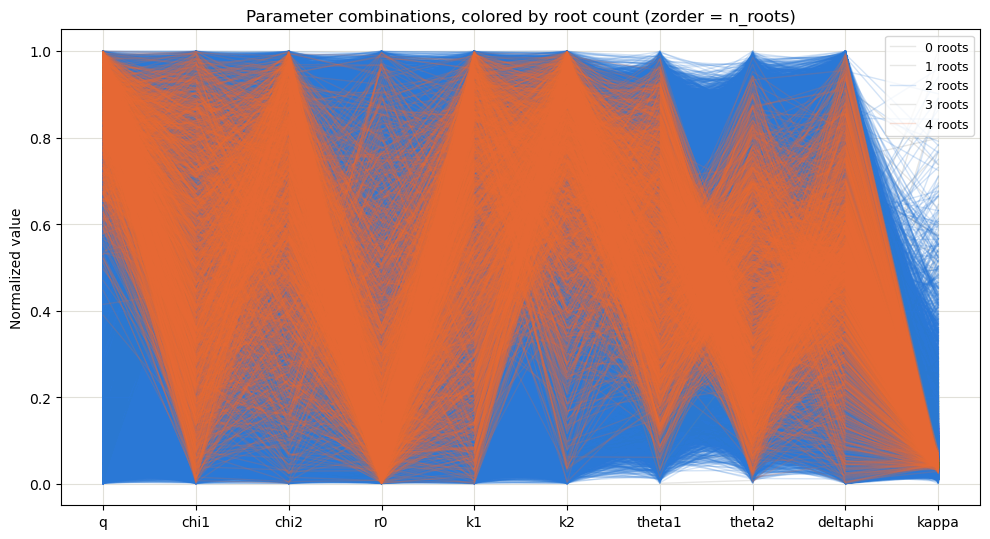

In [142]:
# --- 2. Parallel coordinates plot (built manually for per-line zorder control) ---
df_norm = df.copy()
for p in params:
    df_norm[p] = (df[p] - df[p].min()) / (df[p].max() - df[p].min())
 
fig2, ax2 = plt.subplots(figsize=(10, 5.5))
 
x_positions = range(len(params))
 
# Draw lower-zorder classes first isn't required here since we set zorder
# explicitly per line — but sorting means legend entries come out in a
# sensible order too.
for c in sorted(categories):
    subset = df_norm[df["n_roots"] == c]
    label_used = False
    for _, row in subset.iterrows():
        ax2.plot(
            x_positions, row[params].values,
            color=color_map[c], alpha=0.2, linewidth=1,
            zorder=c,  # <-- zorder tied directly to root count
            label=f"{c} roots" if not label_used else None,
        )
        label_used = True
 
ax2.set_xticks(list(x_positions))
ax2.set_xticklabels(params)
ax2.set_ylabel("Normalized value")
ax2.set_title("Parameter combinations, colored by root count (zorder = n_roots)")
ax2.legend(loc="upper right", fontsize=9)
ax2.grid(True, color="#e1e0d9", linewidth=0.8, zorder=0)
fig2.tight_layout()
#fig2.savefig("roots_parallel_coords.png", dpi=200)
plt.show()

## Reconstructing bifurcating cases

So we want to see what the system before and after the bifurcating evaluation looks like. We can use the 4-root entries into the sampling dictionary above to evolve forwards and backwards, then evolve through. First we choose a random 4-root entry. Then we evolve in both directions from that starting point (orange and blue in the plot below). Then we use the values at the limit of our evolution to start a full evolution (green).

As a note, some cases break and idk why yet. For now, I'm just refreshing a new random 4-root case until they work. I think the bifurcation is a pretty sensitive point, so I'm not surprised we get some weird errors.

In [143]:
# reconstructing a bifurcating system
total_steps = 1000
low = 10 # smallest separation to evolve to
high = 200 # largest separation to evolve to

four_root_df = df[df["n_roots"] == 4]
entry = four_root_df.sample(n=1).iloc[0]

# sample bifurcation
q = entry["q"]
chi1 = entry["chi1"]
chi2 =  entry["chi2"]
r0 = entry["r0"]
k1 = entry["k1"]
k2 = entry["k2"]
theta1 = entry["theta1"]
theta2 = entry["theta2"]
deltaphi = entry["deltaphi"]
kappa = entry["kappa"]

print(q, chi1, chi2, r0, k1, k2, theta1, theta2, deltaphi, kappa)

0.8614100067121782 0.9037890816043148 0.7450335252896056 60.62621976833581 10.861404178239852 8.189169623105045 2.2366620738393586 0.7811345141103687 0.16470746047902685


In [145]:
# if this block throws a delta chi error, just keep rerunning it until it works or rerun the above cell to get a new bifurcation configuration

n1 = round(total_steps * (r0 - low) / (high - low))
n1 = max(1, min(n1, total_steps - 1))  # keep both halves non-empty
n2 = total_steps - n1

chieff = pre.eval_chieff(theta1, theta2, q, chi1, chi2)
chicons= pre_ns.eval_chicons(theta1, theta2, r0, q, chi1, chi2, k1, k2)[0]

deltachi=pre.deltachisampling(kappa=kappa, r=r0, chieff=chieff, q=q, chi1=chi1, chi2=chi1, N=1)

print(deltachi)

test_after=pre_ns_poly.inspiral_orbav(deltachi=deltachi, kappa=kappa,chicons=chicons,r=np.linspace(r0, low, n1),q=q,chi1=chi1,chi2=chi2, k1=k1,k2=k2)
test_bef=pre_ns_poly.inspiral_orbav(deltachi=deltachi, kappa=kappa,chicons=chicons,r=np.linspace(r0, high, n2),q=q,chi1=chi1,chi2=chi2, k1=k1,k2=k2)

0.07293606921299878
True True True
True True True


In [146]:
# extract ID to fully evolve forward
theta1_full = test_bef['theta1'][0][-1]
theta2_full = test_bef['theta2'][0][-1]
deltaphi_full = test_bef['deltaphi'][0][-1]
kappa_full = test_bef['kappa'][0][-1]
chieff_full = pre.eval_chieff(test_bef['theta1'][0][-1], test_bef['theta2'][0][-1], q, chi1, chi2)
deltachi_full = test_bef['deltachi'][0][-1]
chicons_full = test_bef['chicons'][0][-1]

test_all_the_way = pre_ns_poly.inspiral_orbav(deltachi=deltachi_full, kappa=kappa_full,chicons=chicons_full,r=np.linspace(high, low, 1000),q=q,chi1=chi1,chi2=chi2, k1=k1,k2=k2, cyclesign=test_bef['cyclesign'][0][-1])

True True True


Text(0, 0.5, '$\\delta \\chi$')

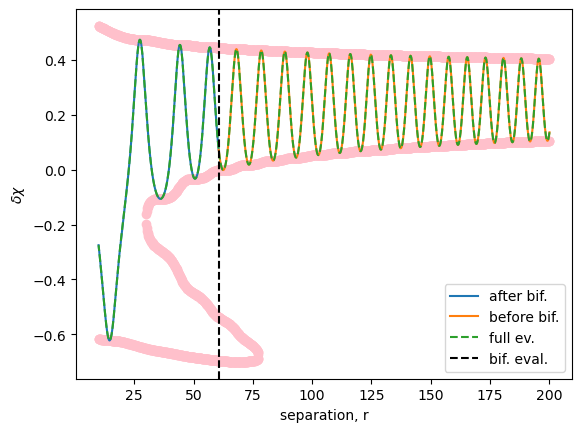

In [150]:
plt.plot(test_after['r'][0], test_after['deltachi'][0], label='after bif.')
plt.plot(test_bef['r'][0], test_bef['deltachi'][0], label='before bif.')
plt.plot(test_all_the_way['r'][0], test_all_the_way['deltachi'][0], linestyle='--', label='full ev.')

root=[]
for i in range(0,len(test_after['deltachi'][0])):
    root.append(pre_ns.deltachiroots(test_after['kappa'][0][i],test_after['u'][0][i],test_after['chicons'][0][i] ,q,chi1,chi2,k1,k2))
for ii, roots in enumerate(root):         
    plt.scatter([test_after['r'][0][ii] for _ in roots], roots, c='pink')

root=[]
for i in range(0,len(test_bef['deltachi'][0])):
    root.append(pre_ns.deltachiroots(test_bef['kappa'][0][i],test_bef['u'][0][i],test_bef['chicons'][0][i] ,q,chi1,chi2,k1,k2))

for ii, roots in enumerate(root):     
    plt.scatter([test_bef['r'][0][ii] for _ in roots], roots, c='pink')

plt.axvline(r0, c='k', linestyle='--', label='bif. eval.')
plt.legend()
plt.xlabel('separation, r')
plt.ylabel(r'$\delta \chi$')